<a href="https://colab.research.google.com/github/Rizkiaan25/Data-Analysis/blob/main/ProductRatings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Dataset**

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

path = "/content/drive/MyDrive/Data Analysis/Apple Sales/"
df = pd.read_csv(path + "AppleSales.csv")

df

Mounted at /content/drive


,Product Name,Product URL,Brand,Sale Price,Mrp,Discount Percentage,Number Of Ratings,Number Of Reviews,Upc,Star Rating,Ram
0,"APPLE iPhone 8 Plus (Gold, 64 GB)",https://www.flipkart.com/apple-iphone-8-plus-g...,Apple,49900,49900,0,3431,356,MOBEXRGV7EHHTGUH,4.6,2 GB
1,"APPLE iPhone 8 Plus (Space Grey, 256 GB)",https://www.flipkart.com/apple-iphone-8-plus-s...,Apple,84900,84900,0,3431,356,MOBEXRGVAC6TJT4F,4.6,2 GB
2,"APPLE iPhone 8 Plus (Silver, 256 GB)",https://www.flipkart.com/apple-iphone-8-plus-s...,Apple,84900,84900,0,3431,356,MOBEXRGVGETABXWZ,4.6,2 GB
3,"APPLE iPhone 8 (Silver, 256 GB)",https://www.flipkart.com/apple-iphone-8-silver...,Apple,77000,77000,0,11202,794,MOBEXRGVMZWUHCBA,4.5,2 GB
4,"APPLE iPhone 8 (Gold, 256 GB)",https://www.flipkart.com/apple-iphone-8-gold-2...,Apple,77000,77000,0,11202,794,MOBEXRGVPK7PFEJZ,4.5,2 GB
...,...,...,...,...,...,...,...,...,...,...,...
57,"APPLE iPhone SE (Black, 64 GB)",https://www.flipkart.com/apple-iphone-se-black...,Apple,29999,39900,24,95909,8161,MOBFWQ6BR3MK7AUG,4.5,4 GB
58,"APPLE iPhone 11 (Purple, 64 GB)",https://www.flipkart.com/apple-iphone-11-purpl...,Apple,46999,54900,14,43470,3331,MOBFWQ6BTFFJKGKE,4.6,4 GB
59,"APPLE iPhone 11 (White, 64 GB)",https://www.flipkart.com/apple-iphone-11-white...,Apple,46999,54900,14,43470,3331,MOBFWQ6BVWVEH3XE,4.6,4 GB
60,"APPLE iPhone 11 (Black, 64 GB)",https://www.flipkart.com/apple-iphone-11-black...,Apple,46999,54900,14,43470,3331,MOBFWQ6BXGJCEYNY,4.6,4 GB


In [ ]:
df.describe()

,Sale Price,Mrp,Discount Percentage,Number Of Ratings,Number Of Reviews,Star Rating
count,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000
mean,80073.887097,88058.064516,9.951613,22420.403226,1861.677419,4.575806
std,34310.446132,34728.825597,7.608079,33768.589550,2855.883830,0.059190
min,29999.000000,39900.000000,0.000000,542.000000,42.000000,4.500000
25%,49900.000000,54900.000000,6.000000,740.000000,64.000000,4.500000
50%,75900.000000,79900.000000,10.000000,2101.000000,180.000000,4.600000
75%,117100.000000,120950.000000,14.000000,43470.000000,3331.000000,4.600000
max,140900.000000,149900.000000,29.000000,95909.000000,8161.000000,4.700000


Hanya angka yang ambil di kolom RAM

In [ ]:
df['Ram'] = df['Ram'].str.extract('(\d+)')

**Exploratory  Data Analyisis (EDA)**

**Top 10 Iphone**

In [ ]:
top_rate = df.sort_values(by=["Star Rating"], ascending=False)
top_rate = top_rate.head(10)
print(top_rate["Product Name"])

15                APPLE iPhone 11 Pro Max (Gold, 64 GB)
20      APPLE iPhone 11 Pro Max (Midnight Green, 64 GB)
17          APPLE iPhone 11 Pro Max (Space Grey, 64 GB)
16     APPLE iPhone 11 Pro Max (Midnight Green, 256 GB)
14               APPLE iPhone 11 Pro Max (Gold, 256 GB)
0                     APPLE iPhone 8 Plus (Gold, 64 GB)
12    Apple iPhone XR (Black, 128 GB) (Includes EarP...
11    Apple iPhone XR (Coral, 128 GB) (Includes EarP...
9     Apple iPhone XR ((PRODUCT)RED, 128 GB) (Includ...
1              APPLE iPhone 8 Plus (Space Grey, 256 GB)
Name: Product Name, dtype: object


**Tipe Dengan Rating Tertinggi**

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
top4 = top_rate.sort_values(by="Number Of Ratings", ascending=False).head(4)

figure = px.bar(
    top4,
    x="Product Name",
    y="Number Of Ratings",
    text="Number Of Ratings",
    title="Top 4 Tipe iPhone dengan Rating Terbanyak",
    color="Product Name"
)


figure.update_traces(textposition='outside')
figure.show()

**Jumlah Review Terbanyak**

In [ ]:
import plotly.express as px

top4 = (
    top_rate.groupby("Product Name")["Number Of Reviews"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

figure = px.pie(
    values=top4
  .values,
    names=top4
  .index,
    title="Top 3 Tipe iPhone Dengan Reviews Terbanyak"
)

figure.update_traces(
    textinfo='percent+value',
    textposition='inside'
)

figure.show()

**Profilling**

In [ ]:
%%capture
!pip install ydata_profiling

In [ ]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Profiling Report", explorative=True)

profile.to_file("EDA.html")

file_path = "/content/drive/MyDrive/Data Analysis/Apple Sales/EDA.html"

from google.colab import files
profile.to_file(file_path)

files.download(file_path)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 79.33it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Pemodelan**

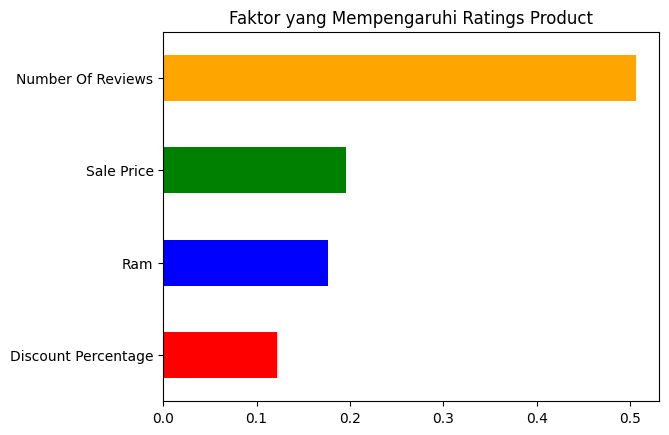

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt


# fitur & target
X = df[['Sale Price', 'Discount Percentage', 'Number Of Reviews', 'Ram']]
y = df['Star Rating']

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values()

# visualisasi
importance.plot(kind='barh',color=['red', 'blue', 'green', 'orange'])
plt.title("Faktor yang Mempengaruhi Ratings Product")
plt.show()

**Evaluasi Model**

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.016615384615382443
R2 Score: 0.6494789473684488


**Github**

In [39]:
# 0. (Opsional tapi disarankan) hapus folder lama biar bersih
!rm -rf Data-Analysis

# 1. Clone repository
!git clone https://github.com/Rizkiaan25/Data-Analysis.git

# 2. Masuk ke folder repo
%cd Data-Analysis

# 3. Set identity
!git config --global user.name "Rizkiaan25"
!git config --global user.email "riskiaan99@gmail.com"

# 4. Pastikan ADA file (WAJIB)
!echo "Upload dari Google Colab" > Ratings-Apple.ipnyb

# 5. Tambahkan semua file
!git add .

# 6. Commit
!git commit -m "first commit dari colab"

# 7. Pastikan branch main
!git branch -M main

Cloning into 'Data-Analysis'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 6 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), done.
/content/Data-Analysis/Data-Analysis/Data-Analysis
[main e28d2ef] first commit dari colab
 1 file changed, 1 insertion(+)
 create mode 100644 Ratings-Apple.ipnyb


In [36]:
# Copy file ke repo
!cp /content/analisis.ipynb /content/Data-Analysis/

# Masuk ke repo
%cd /content/Data-Analysis

# Add, commit, push
!git add .
!git commit -m "tambah file analisis"
!git push origin main

cp: cannot stat '/content/analisis.ipynb': No such file or directory
/content/Data-Analysis
hint: You've added another git repository inside your current repository.
hint: Clones of the outer repository will not contain the contents of
hint: the embedded repository and will not know how to obtain it.
hint: If you meant to add a submodule, use:
hint: 
hint: 	git submodule add <url> Data-Analysis
hint: 
hint: If you added this path by mistake, you can remove it from the
hint: index with:
hint: 
hint: 	git rm --cached Data-Analysis
hint: 
hint: See "git help submodule" for more information.
[main (root-commit) a8d0031] tambah file analisis
 1 file changed, 1 insertion(+)
 create mode 160000 Data-Analysis
fatal: could not read Username for 'https://github.com': No such device or address


In [37]:
!ls /content

Data-Analysis  sample_data


In [40]:
!ls /content
!ls /content/Data-Analysis

Data-Analysis  sample_data
Data-Analysis
